# About this Notebook

This notebook shows:
- a single coding agent that pulls web data (Tavily/Exa/SerpAPI) and graphs it
- a multi-agent workflow where a researcher and a coder collaborate
- **multiple sandboxes running in parallel** - one per user session/agent context (production pattern)

E2B's code interpreter SDK creates secure cloud sandboxes with Jupyter runtimes that agents can use for Python execution and plotting. Multiple sandboxes can run in parallel for isolation between users or sessions.

# Install dependencies

We install LangGraph + LangChain, the E2B Code Interpreter SDK, and web research tools (Tavily; Exa/SerpAPI optional).

In [ ]:
%pip install -q langgraph langchain langchain-openai langchain-community e2b-code-interpreter tavily-python python-dotenv
# Optional providers:
# %pip install -q exa-py google-search-results

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.1/220.1 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.0/310.0 kB 21.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
bigframes 2.31.0 requires rich<14,>=12.4.4, but you have rich 14.3.1 which is incompatible.


# Define API keys

Set API keys for OpenAI, E2B, and at least one web research provider (Tavily/Exa/SerpAPI).

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')
E2B_API_KEY = os.getenv('E2B_API_KEY')
TAVILY_API_KEY = os.getenv('TAVILY_API_KEY')

# Define tools (E2B code interpreter + web search)

We define a persistent E2B sandbox as a tool, and add a web search tool (Tavily in this example).

In [ ]:
import os
import json

from IPython.display import display
from e2b_code_interpreter import Sandbox
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults

if not os.environ.get("E2B_API_KEY"):
    raise ValueError(
        "E2B_API_KEY is not set. Get a key from https://e2b.dev/docs and set it first."
    )

if not os.environ.get("TAVILY_API_KEY"):
    raise ValueError(
        "TAVILY_API_KEY is not set. Set it or swap in Exa/SerpAPI instead."
    )

# Long-lived sandbox that stays alive while the notebook runs
# Note: E2B SDK requires using Sandbox.create()
sandbox = Sandbox.create()
_last_execution = None


@tool
def e2b_code_interpreter(code: str) -> str:
    """Execute Python code in the E2B sandbox and return a JSON summary."""
    global _last_execution
    _last_execution = sandbox.run_code(code)
    summary = {
        "stdout": _last_execution.logs.stdout,
        "stderr": _last_execution.logs.stderr,
        "error": str(_last_execution.error) if _last_execution.error else None,
    }
    return json.dumps(summary, indent=2)


def display_last_e2b_execution() -> None:
    """Render rich outputs (plots, tables) from the most recent execution."""
    if _last_execution is None:
        print("No E2B execution to display yet.")
        return
    if _last_execution.results:
        for r in _last_execution.results:
            display(r)
    if _last_execution.logs.stdout:
        print(_last_execution.logs.stdout)
    if _last_execution.logs.stderr:
        print(_last_execution.logs.stderr)
    if _last_execution.error:
        print(_last_execution.error)


# Tavily web search tool (swap in Exa/SerpAPI if you prefer)
tavily_tool = TavilySearchResults(max_results=5)


# Examples (single-agent + multi-agent)


=== Final assistant message ===
The plot for the US CPI inflation forecast for 2025 has been successfully created. Here is the visualization:

![US CPI Inflation Forecast for 2025](attachment://plot.png)

The plot shows the estimated CPI inflation rates for each month in 2025, with labeled axes and a title. If you need any further analysis or modifications, feel free to ask!

=== Last code-interpreter output (should include the plot) ===


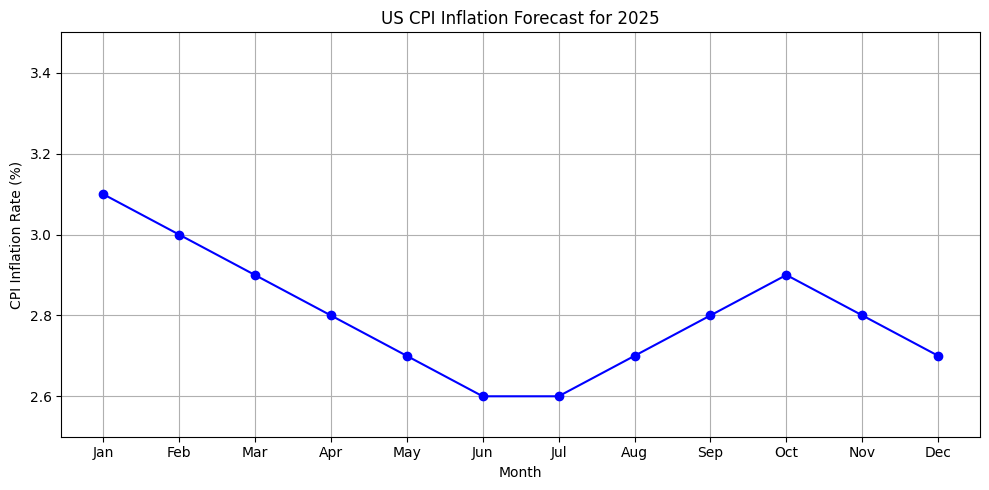

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.prebuilt import ToolNode

def print_last_ai_message(messages) -> None:
    """Print the most recent AI message content."""
    for m in reversed(messages):
        if getattr(m, "type", None) == "ai":
            print(m.content)
            return
    print("No AI message found.")


all_tools = [tavily_tool, e2b_code_interpreter]
all_tool_node = ToolNode(all_tools)

single_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

def single_agent(state: MessagesState):
    llm_with_tools = single_llm.bind_tools(all_tools)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

def route_tools_or_end(state: MessagesState) -> str:
    last = state["messages"][-1]
    return "tools" if getattr(last, "tool_calls", None) else END


single_graph = StateGraph(MessagesState)
single_graph.add_node("agent", single_agent)
single_graph.add_node("tools", all_tool_node)
single_graph.add_conditional_edges("agent", route_tools_or_end)
single_graph.add_edge("tools", "agent")
single_graph.set_entry_point("agent")

single_app = single_graph.compile()

single_prompt = (
    "Find a time series for US CPI inflation in 2025. "
    "Use the web search tool to find a source, then use the code interpreter "
    "to plot the series with labeled axes and a title. "
    "The final step must be a Python tool call that produces the plot."
)

single_result = single_app.invoke({"messages": [("user", single_prompt)]})

print("\n=== Final assistant message ===")
print_last_ai_message(single_result["messages"])

print("\n=== Last code-interpreter output (should include the plot) ===")
display_last_e2b_execution()


Created sandbox: in5k1odvqbrb7a1al9hn8
Tip: add E2B_SANDBOX_ID to your .env to resume next time.

=== Step 1: Create data in the sandbox (and show it) ===
{
  "stdout": [
    "Saved data.json with x,y arrays\nPreview payload:\n{\n  \"x_head\": [\n    0.0,\n    0.05025125628140704,\n    0.10050251256281408,\n    0.15075376884422112,\n    0.20100502512562815,\n    0.2512562814070352,\n    0.30150753768844224,\n    0.35175879396984927,\n    0.4020100502512563,\n    0.45226130653266333\n  ],\n  \"y_head\": [\n    1.0012301533574826,\n    1.4243736782119876,\n    0.9771184260448176,\n    0.4862925833532785,\n    1.0478417776423479,\n    0.6364941485211255,\n    1.813912446818544,\n    3.2196122304791563,\n    1.512818607076811,\n    1.510178366511718\n  ],\n  \"x_min\": 0.0,\n  \"x_max\": 10.0,\n  \"n\": 200\n}\n"
  ],
  "stderr": [],
  "error": null,
  "sandbox_id": "in5k1odvqbrb7a1al9hn8"
}
['Saved data.json with x,y arrays\nPreview payload:\n{\n  "x_head": [\n    0.0,\n    0.050251256281

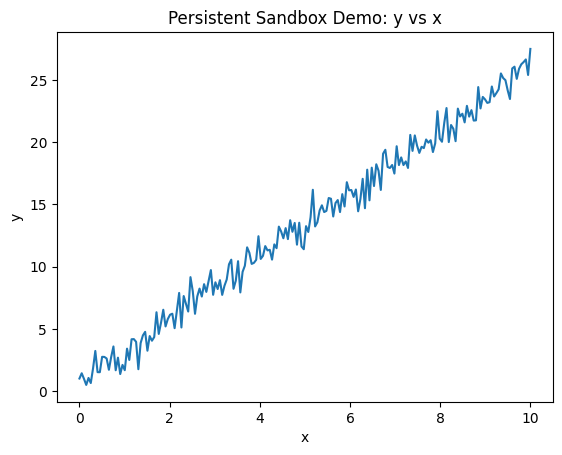

['Using in-memory x,y\n']


In [ ]:
import os
import json
import time
from dotenv import load_dotenv
from IPython.display import display
from e2b_code_interpreter import Sandbox

load_dotenv()

if not os.environ.get("E2B_API_KEY"):
    raise ValueError("E2B_API_KEY is not set.")

E2B_SANDBOX_ID = os.getenv("E2B_SANDBOX_ID")

if E2B_SANDBOX_ID:
    sbx = Sandbox.connect(E2B_SANDBOX_ID, timeout=20 * 60)
    print("Resumed sandbox:", sbx.sandbox_id)
else:
    sbx = Sandbox.beta_create(auto_pause=True, timeout=20 * 60)
    print("Created sandbox:", sbx.sandbox_id)
    print("Tip: add E2B_SANDBOX_ID to your .env to resume next time.")

_last_execution = None

def e2b_code_interpreter(code: str) -> str:
    """Execute Python code in the E2B sandbox and return a JSON summary."""
    global _last_execution
    _last_execution = sbx.run_code(code)
    summary = {
        "stdout": _last_execution.logs.stdout,
        "stderr": _last_execution.logs.stderr,
        "error": str(_last_execution.error) if _last_execution.error else None,
        "sandbox_id": sbx.sandbox_id,
    }
    return json.dumps(summary, indent=2)

def display_last_e2b_execution() -> None:
    """Render rich outputs (plots, tables) from the most recent execution."""
    if _last_execution is None:
        print("No E2B execution to display yet.")
        return
    if _last_execution.results:
        for r in _last_execution.results:
            display(r)
    if _last_execution.logs.stdout:
        print(_last_execution.logs.stdout)
    if _last_execution.logs.stderr:
        print(_last_execution.logs.stderr)
    if _last_execution.error:
        print(_last_execution.error)

def pause_sandbox() -> None:
    """Pause sandbox, persisting filesystem and memory state."""
    sbx.beta_pause()
    print("Paused sandbox:", sbx.sandbox_id)

def resume_sandbox() -> None:
    """Reconnect to sandbox, resuming if paused."""
    global sbx
    sbx = Sandbox.connect(sbx.sandbox_id, timeout=20 * 60)
    print("Connected sandbox:", sbx.sandbox_id)


print("\n=== Step 1: Create data in the sandbox (and show it) ===")
print(e2b_code_interpreter("""
import json
import numpy as np
from pathlib import Path

rng = np.random.default_rng(7)
x = np.linspace(0, 10, 200)
noise = rng.normal(0.0, 1.0, size=x.shape)
y = 2.5 * x + 1.0 + noise

payload = {
    "x_head": x[:10].tolist(),
    "y_head": y[:10].tolist(),
    "x_min": float(x.min()),
    "x_max": float(x.max()),
    "n": int(len(x)),
}

# Persist to filesystem so the demo works even if memory does not persist
Path("data.json").write_text(json.dumps({"x": x.tolist(), "y": y.tolist()}))

print("Saved data.json with x,y arrays")
print("Preview payload:")
print(json.dumps(payload, indent=2))
"""))
display_last_e2b_execution()

print("\nPersist this id as E2B_SANDBOX_ID:", sbx.sandbox_id)

print("\n=== Step 2: Pause sandbox (persist memory + filesystem) ===")
pause_sandbox()

print("\n=== Step 3: Artificial wait (simulates time passing) ===")
time.sleep(60)
print("Waited 60 seconds.")

print("\n=== Step 4: Resume sandbox and plot using previous state ===")
resume_sandbox()

print(e2b_code_interpreter("""
import json
from pathlib import Path
import matplotlib.pyplot as plt

# Prefer memory variables if they exist, else load from disk
if "x" in globals() and "y" in globals():
    print("Using in-memory x,y")
else:
    print("Memory missing, loading from data.json")
    d = json.loads(Path("data.json").read_text())
    x = d["x"]
    y = d["y"]

plt.figure()
plt.plot(x, y)
plt.title("Persistent Sandbox Demo: y vs x")
plt.xlabel("x")
plt.ylabel("y")
plt.show()
"""))
display_last_e2b_execution()


# Two coding agents, two isolated E2B sandboxes, explicit handoff

Sandbox A id: igbd6kco2bqnrdhzjavx4
Sandbox B id: iy1mxqysninbkdni0tqm1

=== Tool call trace ===
tool_call: run_python_a
tool_call: run_python_a
tool_call: publish_artifact
tool_call: fetch_artifact
tool_call: run_python_b

=== Coder A: execution (should not plot) ===
Coder A: sandbox_id=igbd6kco2bqnrdhzjavx4 rich_outputs=0
['{"a": 2.456195597832526, "b": 1.106941895542759, "r2": 0.981570066942203, "first_20_x": [5.4881350392732475, 7.151893663724195, 6.027633760716439, 5.448831829968968, 4.236547993389047, 6.458941130666561, 4.375872112626925, 8.917730007820797, 9.636627605010293, 3.8344151882577773, 7.917250380826646, 5.288949197529044, 5.680445610939323, 9.25596638292661, 0.7103605819788694, 0.8712929970154071, 0.2021839744032572, 8.32619845547938, 7.781567509498505, 8.700121482468191], "first_20_y": [15.846973520289625, 17.799802650947065, 14.921615749379995, 14.184259530177986, 11.093337532780312, 19.076884880483387, 12.889101088493074, 23.381876260937183, 23.866133493695564, 11.4

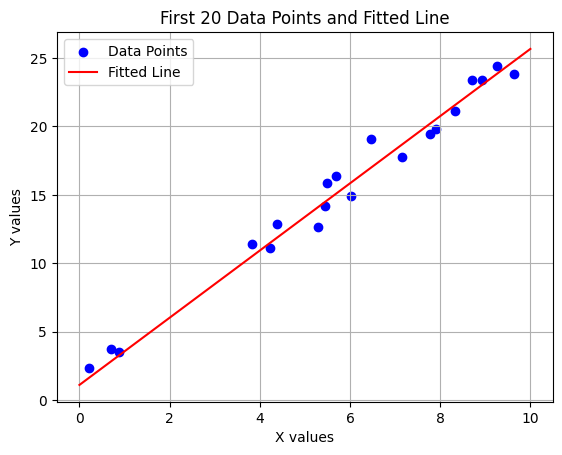


=== Final assistant message ===
The plot of the first 20 data points along with the fitted line has been successfully generated. 

### Interpretation:
1. The blue points represent the first 20 synthetic data points generated from the linear model, showing a clear trend with some noise.
2. The red line indicates the fitted linear regression model, which closely follows the trend of the data points, suggesting a strong linear relationship.
3. The high R² value of approximately 0.98 indicates that the model explains a significant portion of the variance in the data, confirming the effectiveness of the linear fit.


In [ ]:

import json
from uuid import uuid4
from IPython.display import display

from e2b_code_interpreter import Sandbox
from langchain_core.tools import StructuredTool
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.prebuilt import ToolNode



# Small helpers


def print_last_ai_message(messages) -> None:
    """Print the most recent AI message content."""
    for m in reversed(messages):
        if getattr(m, "type", None) == "ai":
            print(m.content)
            return
    print("No AI message found.")

def print_trace(messages):
    print("\n=== Tool call trace ===")
    for m in messages:
        for tc in getattr(m, "tool_calls", []) or []:
            name = tc.get("name") or tc.get("tool") or tc.get("function", {}).get("name")
            print("tool_call:", name)

def display_last_execution(ex, label: str, sbx_ids: dict):
    if ex is None:
        print(f"{label}: no execution")
        return
    n = len(ex.results) if ex.results else 0
    slot = "a" if "A" in label else "b"
    print(f"{label}: sandbox_id={sbx_ids[slot]} rich_outputs={n}")
    if ex.results:
        for r in ex.results:
            display(r)
    if ex.logs.stdout:
        print(ex.logs.stdout)
    if ex.logs.stderr:
        print(ex.logs.stderr)
    if ex.error:
        print(ex.error)



# Stable A/B sandboxes (robust to timeouts)


SBX_IDS = {"a": None, "b": None}
_last_exec = {"a": None, "b": None}

def _get_or_create(slot: str) -> Sandbox:
    sbx_id = SBX_IDS.get(slot)
    if sbx_id:
        try:
            return Sandbox.connect(sbx_id, timeout=20 * 60)
        except Exception:
            SBX_IDS[slot] = None

    sbx = Sandbox.beta_create(auto_pause=True, timeout=20 * 60)
    SBX_IDS[slot] = sbx.sandbox_id
    return sbx

def make_e2b_tool(tool_name: str, slot: str):
    """Create an E2B tool bound to sandbox A or B with a small retry and (optional) plotting guard."""
    def _run(code: str) -> str:
        # Prevent Coder A from plotting (keeps demo honest and deterministic)
        if slot == "a":
            lowered = code.lower()
            if "matplotlib" in lowered or "plt." in lowered or ".show(" in lowered:
                raise ValueError("Plotting is not allowed in run_python_a for this demo.")

        sbx = _get_or_create(slot)

        try:
            ex = sbx.run_code(code)
        except Exception as e:
            # One retry if the sandbox vanished
            if "sandbox was not found" in str(e).lower():
                SBX_IDS[slot] = None
                sbx = _get_or_create(slot)
                ex = sbx.run_code(code)
            else:
                raise

        _last_exec[slot] = ex
        return json.dumps(
            {
                "sandbox_id": sbx.sandbox_id,
                "stdout": ex.logs.stdout,
                "stderr": ex.logs.stderr,
                "error": str(ex.error) if ex.error else None,
                "rich_outputs": len(ex.results) if ex.results else 0,
            },
            indent=2,
        )

    return StructuredTool.from_function(
        func=_run,
        name=tool_name,
        description=f"Run Python in sandbox {slot.upper()} and return JSON logs.",
    )

run_python_a = make_e2b_tool("run_python_a", "a")
run_python_b = make_e2b_tool("run_python_b", "b")



# Explicit artifact handoff (no shared state)


class InMemoryArtifactStore:
    def __init__(self):
        self._data = {}
    def put(self, payload: dict) -> str:
        artifact_id = str(uuid4())
        self._data[artifact_id] = payload
        return artifact_id
    def get(self, artifact_id: str) -> dict:
        return self._data[artifact_id]

artifacts = InMemoryArtifactStore()

def _publish_artifact(payload_json: str) -> str:
    """Publish a JSON payload to the artifact store and return an artifact_id."""
    payload = json.loads(payload_json)
    artifact_id = artifacts.put(payload)
    # Optional: uncomment if you want the notebook to show handoff details
    # print("\n[Artifact published by Coder A]")
    # print("artifact_id:", artifact_id)
    # print("payload keys:", list(payload.keys()))
    return json.dumps({"artifact_id": artifact_id}, indent=2)

def _fetch_artifact(artifact_id: str) -> str:
    """Fetch a previously published JSON artifact by artifact_id."""
    payload = artifacts.get(artifact_id)
    return json.dumps(payload, indent=2)

publish_artifact = StructuredTool.from_function(
    func=_publish_artifact,
    name="publish_artifact",
    description="Publish a JSON payload to the artifact store and return an artifact_id.",
)

fetch_artifact = StructuredTool.from_function(
    func=_fetch_artifact,
    name="fetch_artifact",
    description="Fetch a previously published JSON artifact by artifact_id.",
)



# LangGraph: coder A -> coder B, deterministic stop


llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

coder_a_tools = [run_python_a, publish_artifact]
coder_b_tools = [fetch_artifact, run_python_b]  # ordering nudges fetch before run

coder_a = llm.bind_tools(coder_a_tools)
coder_b = llm.bind_tools(coder_b_tools)

tools_a = ToolNode(coder_a_tools)
tools_b = ToolNode(coder_b_tools)

MAX_STEPS = 10

def route_tools_or_end(state) -> str:
    if state.get("steps", 0) >= MAX_STEPS:
        return END
    last = state["messages"][-1]
    return "tools" if getattr(last, "tool_calls", None) else END

def coder_a_node(state):
    state["steps"] = state.get("steps", 0) + 1
    system = SystemMessage(
        "You are Coder A. Work only in sandbox A. Do not plot. "
        "Write Python that ends by printing ONE JSON string to stdout using print(json.dumps(payload)). "
        "Generate data (200 rows), fit y=a*x+b+noise, compute r2, and create payload with "
        "a, b, r2, first_20_x, first_20_y (lists). "
        "Then call publish_artifact with that payload JSON and stop."
    )
    return {"messages": [coder_a.invoke([system] + state["messages"])], "steps": state["steps"]}

def coder_b_node(state):
    state["steps"] = state.get("steps", 0) + 1

    # After B executed its sandbox once, force a pure-text finish
    if state.get("b_done", False):
        system = SystemMessage(
            "Write exactly 3 interpretation sentences. Do not call tools."
        )
        return {
            "messages": [llm.invoke([system] + state["messages"])],
            "steps": state["steps"],
            "b_done": True,
        }

    system = SystemMessage(
        "You are Coder B.\n"
        "Step 1: Extract the artifact_id from the previous publish_artifact tool result and call fetch_artifact.\n"
        "Step 2: Run Python in sandbox B to plot the first_20 points and the fitted line. Use matplotlib and call plt.show().\n"
        "After the plot is produced, do not call tools again."
    )
    return {"messages": [coder_b.invoke([system] + state["messages"])],
            "steps": state["steps"], "b_done": False}

def tools_b_node(state):
    out = tools_b.invoke(state)
    # Mark done once sandbox B has executed at least once
    out["b_done"] = _last_exec.get("b") is not None
    out["steps"] = state.get("steps", 0)
    return out

graph = StateGraph(MessagesState)
graph.add_node("coder_a", coder_a_node)
graph.add_node("tools_a", tools_a)
graph.add_node("coder_b", coder_b_node)
graph.add_node("tools_b", tools_b_node)

graph.add_conditional_edges("coder_a", route_tools_or_end, {"tools": "tools_a", END: "coder_b"})
graph.add_edge("tools_a", "coder_a")

graph.add_conditional_edges("coder_b", route_tools_or_end, {"tools": "tools_b", END: END})
graph.add_edge("tools_b", "coder_b")

graph.set_entry_point("coder_a")
app = graph.compile()




prompt = """
Coder A: generate synthetic data (200 rows), fit y=a*x+b+noise, publish artifact with a,b,r2,first_20_x,first_20_y.
Coder B: fetch artifact, plot first 20 points + fitted line, then interpret in 3 sentences.
"""

result = app.invoke({"messages": [("user", prompt)], "steps": 0, "b_done": False})


print("Sandbox A id:", SBX_IDS["a"])
print("Sandbox B id:", SBX_IDS["b"])

print_trace(result["messages"])

print("\n=== Coder A: execution (should not plot) ===")
display_last_execution(_last_exec.get("a"), "Coder A", SBX_IDS)

print("\n=== Coder B: execution (should plot) ===")
display_last_execution(_last_exec.get("b"), "Coder B", SBX_IDS)

print("\n=== Final assistant message ===")
print_last_ai_message(result["messages"])
